In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder  #texto a números
from sklearn.pipeline import Pipeline            #automatizar transformaciones
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [57]:
df = pd.read_csv("../data/processed/train_clean.csv")

df.shape


(1460, 77)

In [58]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No Fireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


In [59]:
# Variable objetivo
# SalePrice es lo que queremos predecir

# Respuesta correcta que quiero aprender
y = np.log1p(df["SalePrice"])

In [60]:
# Información de entrada, variables que usaré para predecir 
X = df.drop(columns=["SalePrice"])

In [61]:
X.shape

(1460, 76)

In [62]:
y.shape

(1460,)

In [63]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns

print("Variables categóricas:", len(categorical_features))

print("Variables numéricas:", len(numeric_features))



Variables categóricas: 39
Variables numéricas: 37


In [64]:
X.dtypes.value_counts()

object     39
int64      34
float64     3
Name: count, dtype: int64

In [65]:
# One Hot Encoding lo transforma en columnas numéricas:
#
# GarageType_Attchd | GarageType_Detchd | GarageType_BuiltIn
#        1          |        0          |        0
#        0          |        1          |        0
#        0          |        0          |        1


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"), # Si en producción aparece una categoría nueva, no rompas el modelo
            categorical_features
        ),
        (
            "numeric",
            "passthrough", # las columnas numéricas dejalas igual 
            numeric_features
        )
    ]
)

In [66]:
# Pipeline del modelo
# 1. Preprocesar datos
# 2. Entrenar modelo

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [67]:
# Dividimos los datos en entrenamiento y prueba
#
# Entrenamiento:
# Datos que el modelo usa para aprender
#
# Prueba:
# Datos que el modelo NO ve durante el aprendizaje
# Sirven para medir si realmente aprendió o si solo memorizó

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [68]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 76)
X_test: (292, 76)
y_train: (1168,)
y_test: (292,)


In [69]:
# fit() 
# Aprende la relación entre X_train y y_train

#Aplica One Hot Encoding a las columnas categóricas -> deja pasar las numéricas -> LinearRegression aprende los coeficientes
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](76,)","['Id','MSSubClass','MSZoning',...,'YrSold','SaleType','SaleCondition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,76
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [70]:
# Generamos predicciones sobre datos que el modelo NO vio
# predict() Usa lo aprendido para estimar valores nuevos
y_pred_log = model_pipeline.predict(X_test)

In [71]:
# Para volver a dólares usamos expm1(),  que es la operación inversa de log1p()
# log1p = log(1+x)
# exp1 eʌx−1
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)




# Métricas de Evaluación para Regresión

Las métricas de evaluación nos permiten cuantificar el rendimiento de nuestro modelo predictivo y entender la naturaleza de sus errores.

---

### 1. MAE (Mean Absolute Error / Error Absoluto Medio)

Mide el promedio de las diferencias absolutas entre los valores reales y las predicciones, sin importar su dirección.

$$MAE = \frac{\sum_{i=1}^{n} |y_i - \hat{y}_i|}{n}$$

* **¿Qué mide?** El promedio del error absoluto en las mismas unidades que la variable objetivo.
* **Interpretación:** *"En promedio, las predicciones del modelo se equivocan por $\pm X$ dólares."*

> 💡 **Ejemplo:**
> * **Precio Real ($y$):** 200,000
> * **Precio Predicho ($\hat{y}$):** 190,000
> * **Error Absoluto:** $|200,000 - 190,000| = 10,000$

---

### 2. RMSE (Root Mean Squared Error / Raíz del Error Cuadrático Medio)

Es la raíz cuadrada del promedio de los errores al cuadrado. Al elevar los errores antes de promediarlos, penaliza con mucha mayor fuerza las desviaciones grandes.

$$RMSE = \sqrt{\frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{n}}$$

* **¿Qué mide?** La magnitud del error, pero con un castigo directo a los fallos graves.
* **Interpretación:** *¿Qué tan graves son mis peores errores?* Si el RMSE es mucho más alto que el MAE, significa que el modelo comete algunos errores muy grandes que debes revisar.

> **Comparación de penalización:**
> * Un error de **5,000** elevado al cuadrado aporta poco al total.
> * Un error de **100,000** elevado al cuadrado castiga masivamente la métrica del modelo.

---

### 3. $R^2$ (Coeficiente de Determinación)

Indica qué proporción de la varianza total de la variable objetivo (`SalePrice`) es explicada por las variables independientes del modelo.

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

* **¿Qué mide?** La calidad global del ajuste del modelo en comparación con una predicción base (la media).
* **Escala de Interpretación:**
  * **`0.00`** $\rightarrow$ El modelo no explica nada de la variabilidad (es igual que predecir siempre el promedio).
  * **`0.50`** $\rightarrow$ Explica el 50% de la variación.
  * **`0.85`** $\rightarrow$ Explica muy bien el comportamiento de los precios.
  * **`1.00`** $\rightarrow$ Ajuste y predicción perfectos (¡cuidado con el overfitting!).

In [72]:
#¿Cuánto me equivoco en promedio?
mae = mean_absolute_error(
    y_test_real,
    y_pred_real
)

#¿Qué tan graves son mis errores grandes?
rmse = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_pred_real
    )
)

# ¿Qué porcentaje del comportamiento de los precios entiende mi modelo?
r2 = r2_score(
    y_test_real,
    y_pred_real
)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 17,187.42
RMSE : 25,718.39
R²   : 0.9138


In [73]:
# Comparación entre valores reales y predicciones

# Crear tabla para analizar resultados
comparison_df  = pd.DataFrame({
    "Real": y_test_real,
    "Predicho": y_pred_real
})

comparison_df["Error"] = (comparison_df["Real"] - comparison_df["Predicho"])
comparison_df.head(10)

,Real,Predicho,Error
892,154500.0,152637.171384,1862.828616
1105,325000.0,330024.978327,-5024.978327
413,115000.0,100404.104772,14595.895228
522,159000.0,161275.702827,-2275.702827
1036,315500.0,344325.002759,-28825.002759
614,75500.0,80496.833910,-4996.833910
218,311500.0,261907.210053,49592.789947
1160,146000.0,140603.790391,5396.209609
649,84500.0,75139.776330,9360.223670
887,135500.0,139198.261339,-3698.261339


In [74]:
comparison_df["Error_absoluto"] = (
    comparison_df["Error"]
).abs()

comparison_df.sort_values(
    by= "Error_absoluto",
    ascending=False
).head(10)

,Real,Predicho,Error,Error_absoluto
898,611657.0,422962.033712,188694.966288,188694.966288
774,395000.0,289614.234331,105385.765669,105385.765669
691,755000.0,671215.298972,83784.701028,83784.701028
588,143000.0,226578.126306,-83578.126306,83578.126306
1046,556581.0,478672.600870,77908.399130,77908.399130
628,135000.0,211610.938816,-76610.938816,76610.938816
581,253293.0,329396.258492,-76103.258492,76103.258492
58,438780.0,509616.427320,-70836.427320,70836.427320
744,180000.0,240075.747547,-60075.747547,60075.747547
607,225000.0,168226.264678,56773.735322,56773.735322


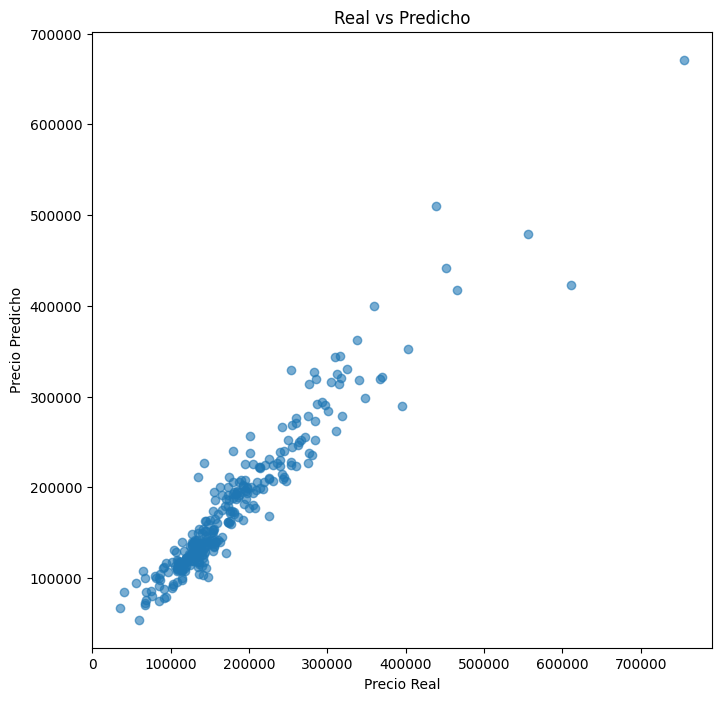

In [ ]:
plt.figure(figsize=(8,8))

# comparar variables punto por punto 
plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.6
)

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")

plt.title(
    "Real vs Predicho"
)

plt.show()

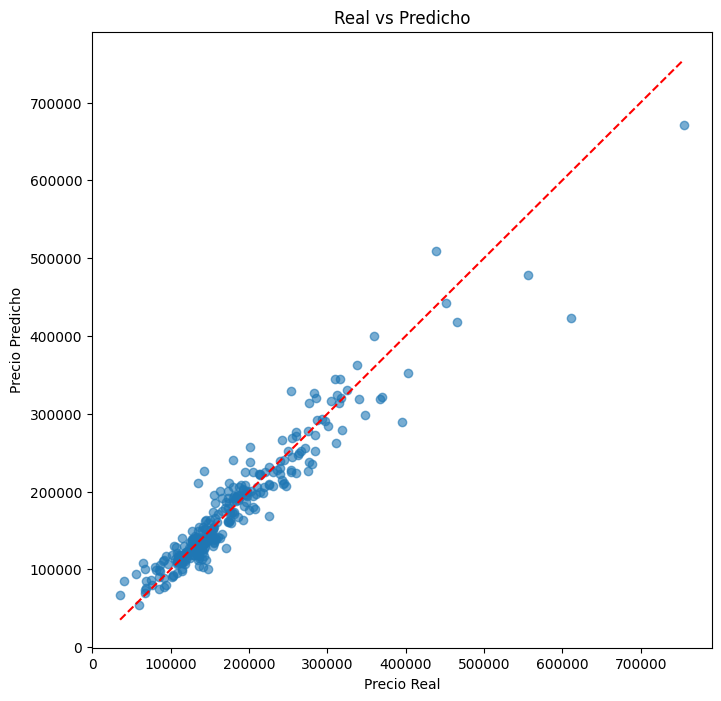

In [76]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.6
)

plt.plot(
    [
        y_test_real.min(),
        y_test_real.max()
    ],
    [
        y_test_real.min(),
        y_test_real.max()
    ],
    "r--"
)

plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")

plt.title(
    "Real vs Predicho"
)

plt.show()